In [1]:
!pip install -qq monai torchmetrics timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.6 MB/s eta 0:00:00


In [2]:
!mkdir precise-challenge-dataset
!cp -r /kaggle/input/precise-challenge-val-dataset/PRECISE_Challenge2025_Val precise-challenge-dataset
!cp -r /kaggle/input/precise-challenge-dataset/PRECISE_Challenge2025_Train precise-challenge-dataset

In [3]:
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
import albumentations as A
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import timm 
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from monai.metrics import compute_hausdorff_distance, compute_surface_dice
from torchmetrics.classification import MulticlassAUROC
import glob
import pandas as pd
from torchvision import transforms

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-08-13 22:05:25.680137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755122726.005972      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755122726.106298      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Exploration

In [5]:
# !ls '/kaggle/input/precise-challenge-dataset'

In [6]:
base_path = '/kaggle/working/precise-challenge-dataset/PRECISE_Challenge2025_Train'

subfolders = ['benign', 'malignant', 'normal']

for folder in subfolders:
    folder_path = os.path.join(base_path, folder)
    print(f"\nFiles in {folder}:")
    print(os.listdir(folder_path)[:5])


Files in benign:
['PACE_01249_001_BUSBRA_mask.png', 'PACE_03136_001_BUSI_mask.png', 'PACE_00490_001_BUSBRA.png', 'PACE_02807_001_BUSI.png', 'PACE_02676_001_BUSI.png']

Files in malignant:
['PACE_01868_002_BUSBRA_mask.png', 'PACE_03629_002_BREAST_mask.png', 'PACE_03568_002_BREAST.png', 'PACE_02258_002_BUSI_mask.png', 'PACE_01363_002_BUSBRA_mask.png']

Files in normal:
['PACE_02059_000_BUSI.png', 'PACE_02005_000_BUSI.png', 'PACE_02053_000_BUSI_mask.png', 'PACE_01918_000_BUSI.png', 'PACE_02080_000_BUSI.png']


In [7]:
for folder in subfolders:
    folder_path = os.path.join(base_path, folder)
    num_files = len(os.listdir(folder_path))
    print(f"{folder}: {num_files} images")

benign: 3882 images
malignant: 1912 images
normal: 454 images


In [8]:
for folder in subfolders:
    folder_path = os.path.join(base_path, folder)
    files = os.listdir(folder_path)

    images = [f for f in files if '_mask' not in f]
    masks = [f.replace('.png', '_mask.png') for f in images]

    # Check if all masks exist
    missing_masks = [mask for mask in masks if mask not in files]
    print(f"{folder} - Missing masks: {missing_masks}")

benign - Missing masks: ['PACE_03668_001_BREAST_mask.png', 'PACE_03670_001_BREAST_mask.png', 'PACE_03665_001_BREAST_mask.png', 'PACE_03664_001_BREAST_mask.png']
malignant - Missing masks: []
normal - Missing masks: []


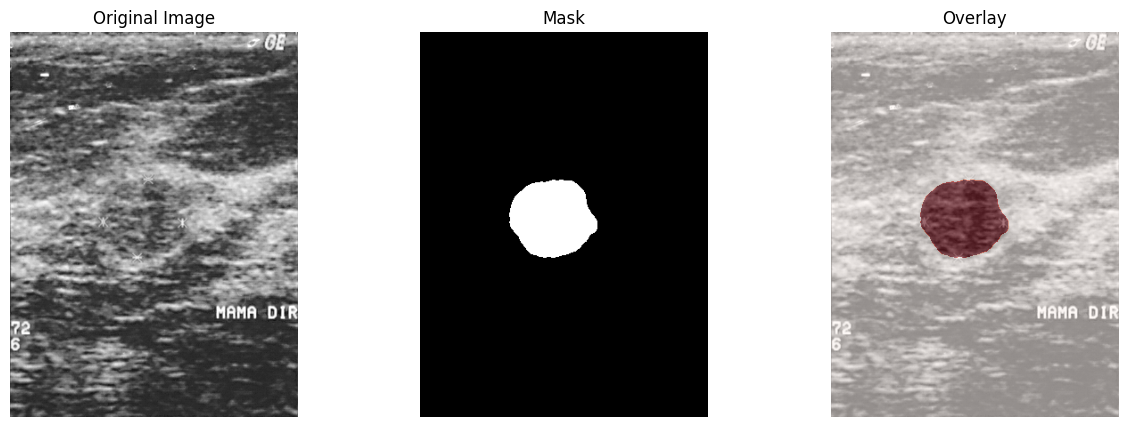

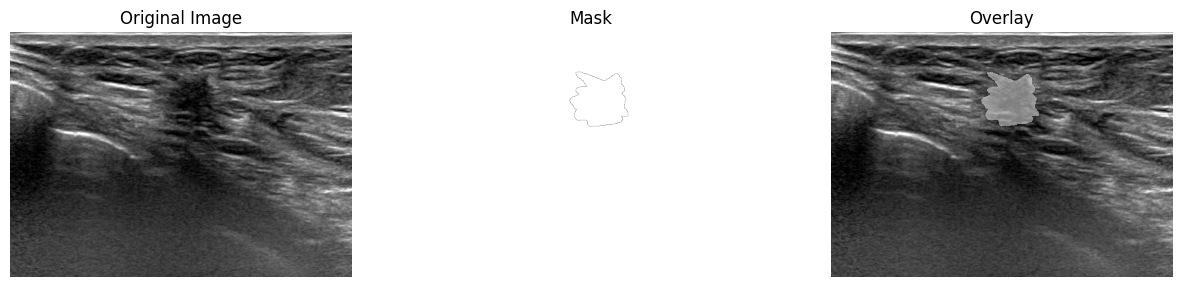

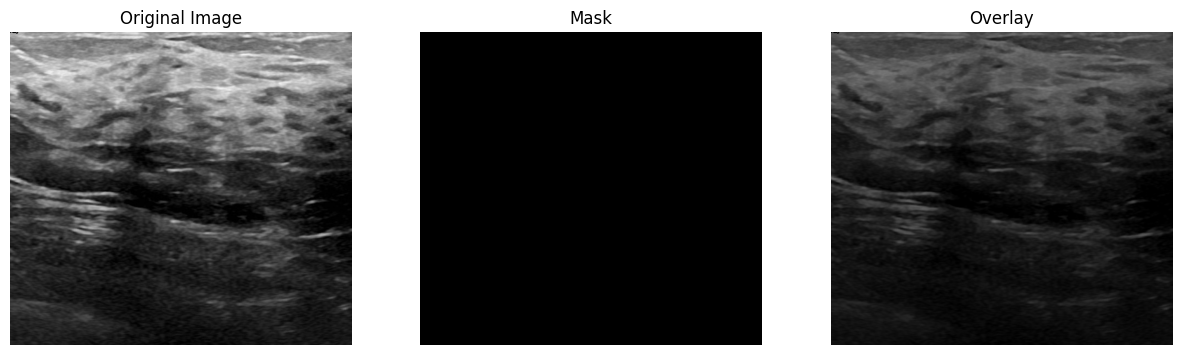

In [9]:
for folder in subfolders:
    folder_path = os.path.join(base_path, folder)
    files = os.listdir(folder_path)

    images = [f for f in files if '_mask' not in f]
    sample_image = images[0]
    sample_mask = sample_image.replace('.png', '_mask.png')

    img = Image.open(os.path.join(folder_path, sample_image))
    mask = Image.open(os.path.join(folder_path, sample_mask))

    img_array = np.array(img)
    mask_array = np.array(mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(mask_array, cmap='gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')

    axes[2].imshow(img_array, cmap='gray')
    axes[2].imshow(mask_array, alpha=0.5, cmap='Reds')
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.show()

# Preprocessing

**Defining Necessary Functions**

In [10]:
BASE_PATH = "/kaggle/working/precise-challenge-dataset/PRECISE_Challenge2025_Train"
CLASSES = ["benign", "malignant", "normal"]

In [11]:
def get_valid_pairs(base_path, classes):
    """Returns list of (image_path, mask_path) for valid pairs. Handles missing masks."""
    pairs = []
    for cls in classes:
        img_dir = os.path.join(base_path, cls)
        for img_file in os.listdir(img_dir):
            if "_mask" not in img_file:  # Skip mask files
                img_path = os.path.join(img_dir, img_file)
                mask_file = img_file.replace(".png", "_mask.png")
                mask_path = os.path.join(img_dir, mask_file)

                # Handle missing masks
                if not os.path.exists(mask_path):
                    print(f"Warning: Missing mask for {img_path}")
                else:
                    pairs.append((img_path, mask_path))
    return pairs

# Get all valid pairs
all_pairs = get_valid_pairs(BASE_PATH, CLASSES)
print(f"Total valid pairs: {len(all_pairs)}")

Total valid pairs: 3116


In [12]:
import random
def create_average_reference_from_pairs(pairs, num_samples=10, target_size=(256, 256), save_path="avg_reference.npy"):
    """Selects random images from (img, mask) pairs and saves average reference as .npy."""
    random.seed(42)  # for consistent reference
    selected_pairs = random.sample(pairs, min(num_samples, len(pairs)))
    images = []

    for img_path, _ in selected_pairs:
        img = cv2.imread(img_path)

        if img is None:
            print(f"Warning: Could not load image at {img_path}")
            continue

        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        img = cv2.resize(img, target_size) / 255.0
        images.append(img)

    if len(images) == 0:
        raise ValueError("No valid images found to compute average reference.")

    avg_ref = np.mean(images, axis=0).astype(np.float32)
    np.save(save_path, avg_ref)
    print(f"Saved average reference image to {save_path}")
    return avg_ref


In [13]:
from skimage.exposure import match_histograms

def preprocess_image(img, target_size=(256, 256), reference_image=None):
    """Normalize, resize, histogram-match, and enhance ultrasound image."""
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    img = cv2.resize(img, target_size) / 255.0

    # if reference_image is not None:
    #     img = match_histograms(img, reference_image, channel_axis=None)

    # CLAHE
    # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # img = clahe.apply((img * 255).astype(np.uint8)) / 255.0

    return img.astype(np.float32)

def preprocess_mask(mask, target_size=(256, 256)):
    # Binarize and resize mask.
    if len(mask.shape) == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)

    # Ensure mask is in a supported format before resizing
    mask = mask.astype(np.uint8)

    mask = cv2.resize(mask, target_size)
    mask = (mask > 0).astype(np.float32)  # Binarize
    return mask

In [14]:
# path = os.path.join(BASE_PATH, CLASSES[0])
# random_num = random.randint(1, len(os.listdir(path)))
# img = os.listdir(path)[random_num]
# img = os.path.join(path, img)


In [15]:
# Define augmentations
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
], additional_targets={'mask': 'mask'})

def apply_augmentation(img, mask):
    """Apply Albumentations augmentations to image-mask pair."""
    augmented = augmenter(image=img, mask=mask)
    return augmented["image"].astype(np.float32), augmented["mask"].astype(np.float32)

**Dataloader**

In [16]:
class UltrasoundDataset(Dataset):
    def __init__(self, pairs, augment=False, target_size=(256, 256), reference_image=None):
        self.pairs = pairs
        self.augment = augment
        self.target_size = target_size
        self.reference_image = reference_image  # Average reference for histogram matching

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # Load image and mask
        img = np.array(Image.open(img_path))
        mask = np.array(Image.open(mask_path)) if mask_path is not None else None

        # Preprocess with histogram matching using the shared reference image
        img = preprocess_image(img, self.target_size, reference_image=self.reference_image)
        mask = preprocess_mask(mask, self.target_size)

        # Augment if training
        if self.augment:
            img, mask = apply_augmentation(img, mask)

        # Replicate the single channel 3 times for ConvNeXt
        img = np.repeat(np.expand_dims(img, axis=0), 3, axis=0)

        # Add channel dimension to mask
        mask = np.expand_dims(mask, axis=0)

        # Extract class label from path
        cls_label = 0 if "benign" in img_path else 1 if "malignant" in img_path else 2

        return {
            "image": torch.tensor(img, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
            "class": torch.tensor(cls_label, dtype=torch.long)
        }


In [17]:
avg_reference = create_average_reference_from_pairs(
    all_pairs,
    num_samples=10,
    target_size=(256, 256),
    save_path="avg_reference.npy"
)

Saved average reference image to avg_reference.npy


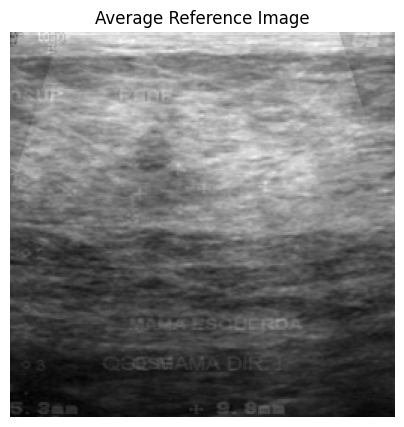

In [18]:
# Load the average reference image
avg_reference = np.load("avg_reference.npy")

# Visualize
plt.figure(figsize=(5, 5))
plt.imshow(avg_reference, cmap='gray')
plt.title("Average Reference Image")
plt.axis('off')
plt.show()

In [19]:
# Split into train/val/test (80/10/10)
train_pairs, test_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)
val_pairs, test_pairs = train_test_split(test_pairs, test_size=0.5, random_state=42)

# Create datasets
train_dataset = UltrasoundDataset(train_pairs, augment=True, reference_image=avg_reference)
val_dataset = UltrasoundDataset(val_pairs, augment=False, reference_image=avg_reference)
test_dataset = UltrasoundDataset(test_pairs, augment=False, reference_image=avg_reference)

# Create loaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [20]:
def plot_sample(batch):
    """Plot a batch of images, masks, and overlays."""
    images = batch["image"].numpy()
    masks = batch["mask"].numpy()
    classes = batch["class"].numpy()
    class_names = {0: "benign", 1: "malignant", 2: "normal"}

    fig, axes = plt.subplots(4, 3, figsize=(16, 16))
    for i in range(4):
        # Original image
        axes[i, 0].imshow(images[i][0], cmap="gray")
        axes[i, 0].set_title(f"Image\nClass: {class_names[classes[i]]}")
        axes[i, 0].axis("off")

        # Mask
        axes[i, 1].imshow(masks[i][0], cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

        # Overlay
        axes[i, 2].imshow(images[i][0], cmap="gray")
        axes[i, 2].imshow(masks[i][0], alpha=0.5, cmap="Reds")
        axes[i, 2].set_title("Overlay")
        axes[i, 2].axis("off")

        # Augmented (if training)
        # if images.shape[0] > i+4:
        #     axes[i, 3].imshow(images[i+4][0], cmap="gray")
        #     axes[i, 3].set_title("Augmented")
        #     axes[i, 3].axis("off")
    plt.tight_layout()
    plt.show()

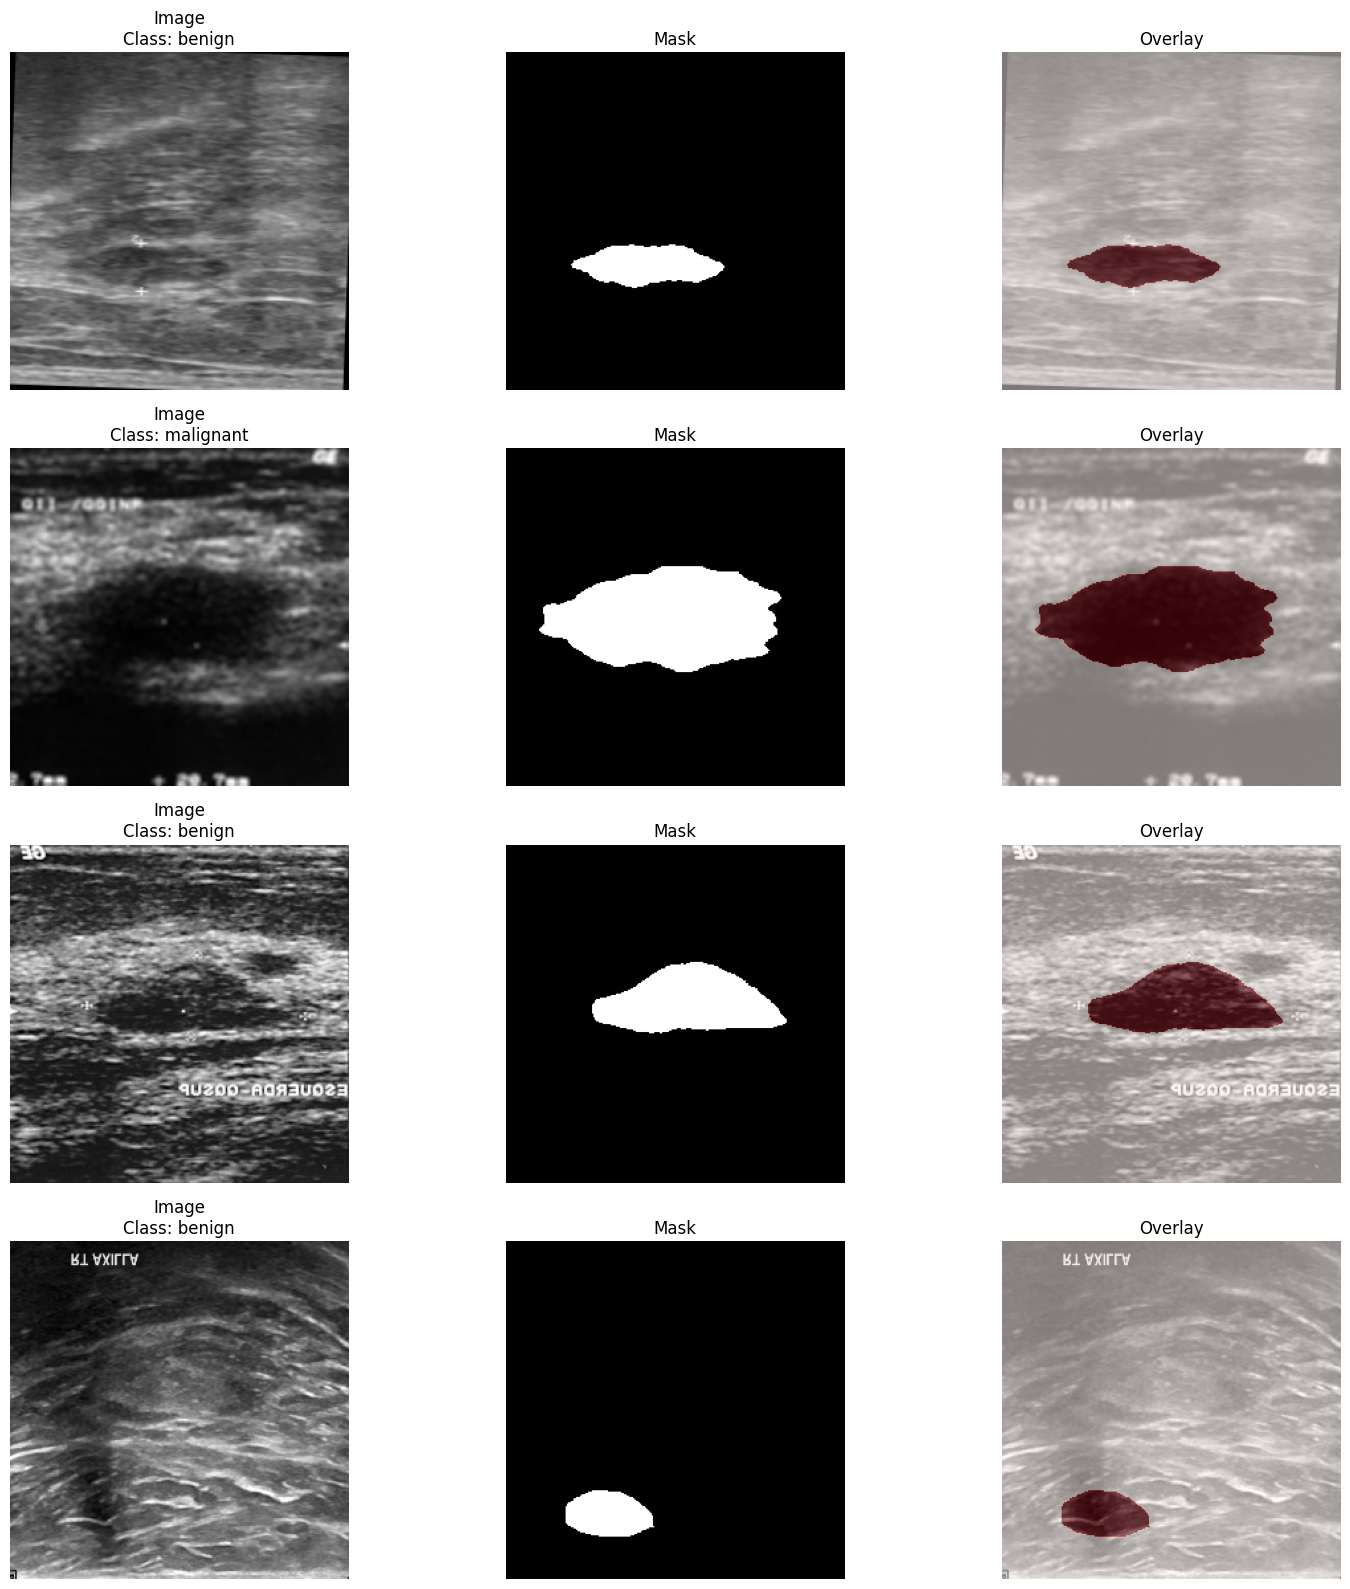

In [21]:
sample_batch = next(iter(train_loader))
plot_sample(sample_batch)

# Model Architecture

In [22]:
# timm.list_models()

In [23]:
class ConvNeXtBlock(nn.Module):
    def __init__(self, dim, layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)  # depthwise conv
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones(dim)) if layer_scale_init_value > 0 else None

    def forward(self, x):
        shortcut = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)  # NCHW -> NHWC
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2)  # NHWC -> NCHW
        return shortcut + x

In [24]:
class UNetConvNeXt(nn.Module):
    def __init__(self, num_classes=3, seg_out_channels=1):
        super(UNetConvNeXt, self).__init__()

        self.encoder = timm.create_model('convnext_base', pretrained=True, features_only=True)
        encoder_channels = self.encoder.feature_info.channels()  # e.g., [96, 192, 384, 768]

        # Decoder with ConvNeXt-style blocks
        self.decoder4 = self._decoder_block(encoder_channels[3], encoder_channels[2])
        self.decoder3 = self._decoder_block(encoder_channels[2], encoder_channels[1])
        self.decoder2 = self._decoder_block(encoder_channels[1], encoder_channels[0])
        self.decoder1 = self._decoder_block(encoder_channels[0], 64)

        self.final_segmentation = nn.Conv2d(64, seg_out_channels, kernel_size=1)

        # Classifier using ConvNeXt block before pooling
        self.classifier_block = ConvNeXtBlock(encoder_channels[-1])
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(encoder_channels[-1], num_classes)
        )

    def _decoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),  # match dims
            ConvNeXtBlock(out_channels),
            ConvNeXtBlock(out_channels)
        )

    def forward(self, x):
        # Encoder
        feats = self.encoder(x)  # list of feature maps
        e1, e2, e3, e4 = feats

        # Classification head
        cls_feat = self.classifier_block(e4)
        cls_out = self.classifier(cls_feat)

        # Decoder
        d4 = self.decoder4(e4)
        d4 = F.interpolate(d4, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.decoder3(d4 + e3)

        d3 = F.interpolate(d3, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.decoder2(d3 + e2)

        d2 = F.interpolate(d2, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.decoder1(d2 + e1)

        seg_out = self.final_segmentation(d1)

        return seg_out, cls_out

In [25]:
# Instantiate the model
model = UNetConvNeXt()

# Print model summary to verify
print(model)

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

UNetConvNeXt(
  (encoder): FeatureListNet(
    (stem_0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (stem_1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    (stages_0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=512, out_features=128, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), g

In [26]:
# Dummy input: batch of grayscale images (e.g., B=4, 1 channel, 256x256)
dummy_input = torch.randn(4, 1, 256, 256)

# Convert to 3 channels (ConvNeXt expects 3-channel RGB)
dummy_input = dummy_input.repeat(1, 3, 1, 1)  # Shape: (4, 3, 256, 256)

# Initialize the model
model = UNetConvNeXt(num_classes=3, seg_out_channels=1)

# Run forward pass
seg_output, cls_output = model(dummy_input)

# Print output shapes
print("Segmentation output shape:", seg_output.shape)  # Expected: (4, 1, 256, 256) or smaller if unpadded
print("Classification output shape:", cls_output.shape)  # Expected: (4, 3)

Segmentation output shape: torch.Size([4, 1, 64, 64])
Classification output shape: torch.Size([4, 3])


In [27]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 1 - dice

# Focal Loss for binary segmentation
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Apply sigmoid to inputs (since model outputs logits)
        p = torch.sigmoid(inputs)
        ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        p_t = p * targets + (1 - p) * (1 - targets)  # p_t = probability of true class
        loss = ce_loss * ((1 - p_t) ** self.gamma)

        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5, smooth=1e-6, reduction='mean'):
        super(TverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
        self.reduction = reduction

    def forward(self, inputs, targets):

        inputs = torch.sigmoid(inputs)

        inputs = inputs.view(inputs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        TP = (inputs * targets).sum(dim=1)
        FP = ((1 - targets) * inputs).sum(dim=1)
        FN = (targets * (1 - inputs)).sum(dim=1)

        tversky_index = (TP + self.smooth) / (
            TP + self.alpha * FP + self.beta * FN + self.smooth
        )

        loss = 1 - tversky_index  

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [28]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()
cls_loss_fn = nn.CrossEntropyLoss()

tversky_loss = TverskyLoss(alpha=0.3, beta=0.7)
focal_loss = FocalLoss(alpha=0.25, gamma=2.0)


In [29]:
model = UNetConvNeXt(num_classes=3, seg_out_channels=1).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, mode='min', patience=3, factor=0.5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader) * 50, eta_min=1e-6)

In [30]:
from tqdm import tqdm

In [31]:
def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for batch in loop:
        imgs = batch['image'].to(device)
        masks = batch['mask'].to(device)
        labels = batch['class'].to(device)

        optimizer.zero_grad()
        seg_out, cls_out = model(imgs)

        seg_out = F.interpolate(seg_out, size=masks.shape[2:], mode='bilinear', align_corners=False)

        seg_loss = focal_loss(seg_out, masks) + bce_loss(seg_out, masks)
        cls_loss = cls_loss_fn(cls_out, labels)

        loss = seg_loss + cls_loss
        loss.backward()
        optimizer.step()

        # scheduler.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]["lr"])

    return total_loss / len(loader)


In [32]:
def validate(model, loader):
    model.eval()
    total_loss = 0

    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch in loop:
            imgs = batch['image'].to(device)
            masks = batch['mask'].to(device)
            labels = batch['class'].to(device)

            seg_out, cls_out = model(imgs)
            seg_out = F.interpolate(seg_out, size=masks.shape[2:], mode='bilinear', align_corners=False)

            seg_loss = focal_loss(seg_out, masks) + bce_loss(seg_out, masks)
            cls_loss = cls_loss_fn(cls_out, labels)

            loss = seg_loss + cls_loss
            total_loss += loss.item()

            loop.set_postfix(val_loss=loss.item())

    return total_loss / len(loader)


## Train the model

### Subtask:
Execute the training loop for a specified number of epochs, including validation and saving checkpoints.


In [33]:
EPOCHS = 25
best_val_loss = float('inf')
patience = 5
counter = 0  

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_loss = validate(model, val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
        print("✅ Saved new best model!")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break


Epoch 1: Train Loss = 2.1797, Val Loss = 1.1192
✅ Saved new best model!


Epoch 2: Train Loss = 1.1335, Val Loss = 1.2254


Epoch 3: Train Loss = 1.0813, Val Loss = 1.0004
✅ Saved new best model!


Epoch 4: Train Loss = 0.9770, Val Loss = 0.9566
✅ Saved new best model!


Epoch 5: Train Loss = 0.9274, Val Loss = 0.8695
✅ Saved new best model!


...

Epoch 18: Train Loss = 0.5376, Val Loss = 0.6447


Epoch 19: Train Loss = 0.4877, Val Loss = 0.5729


Epoch 20: Train Loss = 0.4519, Val Loss = 0.5945


Epoch 21: Train Loss = 0.4258, Val Loss = 0.5642


Epoch 22: Train Loss = 0.4256, Val Loss = 0.5541
Early stopping.


# Evaluate the model on the test set

In [34]:
def compute_dice(pred, target, threshold=0.5, eps=1e-5):
    pred = (pred > threshold).float()
    target = target.float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2. * intersection + eps) / (union + eps)
    return dice.mean().item()

In [35]:
def compute_hd95_nsd(pred, target, spacing=(1.0, 1.0)):
    pred_bin = (pred > 0.5).cpu()
    target_bin = (target > 0.5).cpu()

    hd95_list = []
    nsd_list = []

    for p, t in zip(pred_bin, target_bin):
        p = p.unsqueeze(0)  # (1, 1, H, W)
        t = t.unsqueeze(0)

        hd = compute_hausdorff_distance(p, t, percentile=95.0, spacing=spacing)
        nsd = compute_surface_dice(p, t, class_thresholds=[1.0], spacing=spacing)

        hd95_list.append(hd.item())
        nsd_list.append(nsd.item())

    return np.mean(hd95_list), np.mean(nsd_list)


In [36]:
def compute_classification_metrics(y_true, y_probs, num_classes=3):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    auc = roc_auc_score(y_true, y_probs, multi_class='ovr')

    fpr, tpr, thresholds = roc_curve(y_true == 1, y_probs[:, 1])  # Example: for class 1
    sensitivity_90spec = tpr[np.argmax(fpr <= 0.10)]  # Sensitivity @90% specificity
    specificity_90sens = 1 - fpr[np.argmax(tpr >= 0.90)]  # Specificity @90% sensitivity

    return auc, sensitivity_90spec, specificity_90sens


In [37]:
def test_model(model, test_loader):
    model.eval()
    all_dice = []
    all_hd95 = []
    all_nsd = []

    y_true = []
    y_probs = []

    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(device)
            masks = batch['mask'].to(device)
            labels = batch['class'].to(device)

            seg_out, cls_out = model(imgs)
            seg_out = F.interpolate(seg_out, size=masks.shape[2:], mode='bilinear', align_corners=False)
            
            seg_probs = torch.sigmoid(seg_out)
            dice = compute_dice(seg_probs, masks)
            hd95, nsd = compute_hd95_nsd(seg_probs, masks)

            all_dice.append(dice)
            all_hd95.append(hd95)
            all_nsd.append(nsd)

            probs = torch.softmax(cls_out, dim=1)
            y_probs.extend(probs.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    auc, sens_90spec, spec_90sens = compute_classification_metrics(y_true, y_probs)

    print("Segmentation Results:")
    print(f"Mean Dice: {np.mean(all_dice):.4f}")
    print(f"Mean NSD: {np.mean(all_nsd):.4f}")
    print(f"Mean HD95: {np.mean(all_hd95):.4f}")
    print()
    print("Classification Results:")
    print(f"AUC: {auc:.4f}")
    print(f"Sensitivity @90% Specificity: {sens_90spec:.4f}")
    print(f"Specificity @90% Sensitivity: {spec_90sens:.4f}")

In [38]:
model.load_state_dict(torch.load("best_model.pth"))
test_model(model, test_loader)

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.11/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(


Segmentation Results:
Mean Dice: 0.7022
Mean NSD: nan
Mean HD95: nan

Classification Results:
AUC: 0.9347
Sensitivity @90% Specificity: 0.0000
Specificity @90% Sensitivity: 0.6667


In [39]:
def show_predictions(model, loader, class_map=None, num_samples=5):
    """
    Visualizes input, ground truth mask, predicted mask, and class labels.
    - class_map: dict like {0: 'benign', 1: 'malignant', 2: 'normal'}
    """
    model.eval()
    count = 0

    with torch.no_grad():
        for batch in loader:
            imgs = batch['image'].to(device)
            masks = batch['mask'].to(device)
            labels = batch['class'].to(device)

            seg_out, cls_out = model(imgs)

            seg_out = F.interpolate(seg_out, size=masks.shape[2:], mode='bilinear', align_corners=False)
            seg_probs = torch.sigmoid(seg_out)
            seg_preds = (seg_probs > 0.5).float()

            cls_probs = torch.softmax(cls_out, dim=1)
            cls_preds = torch.argmax(cls_probs, dim=1)

            for i in range(imgs.size(0)):
                if count >= num_samples:
                    return

                img = imgs[i, 0].cpu().numpy()
                gt_mask = masks[i, 0].cpu().numpy()
                pred_mask = seg_preds[i, 0].cpu().numpy()

                true_class = labels[i].item()
                pred_class = cls_preds[i].item()

                true_class_str = class_map[true_class] if class_map else str(true_class)
                pred_class_str = class_map[pred_class] if class_map else str(pred_class)

                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img, cmap='gray')
                axs[0].set_title(f'Input\nPredicted Class: {pred_class_str}\nTrue Class: {true_class_str}')
                axs[1].imshow(gt_mask, cmap='gray')
                axs[1].set_title('Ground Truth Mask')
                axs[2].imshow(pred_mask, cmap='gray')
                axs[2].set_title('Predicted Mask')

                for ax in axs:
                    ax.axis('off')
                plt.tight_layout()
                plt.show()

                count += 1

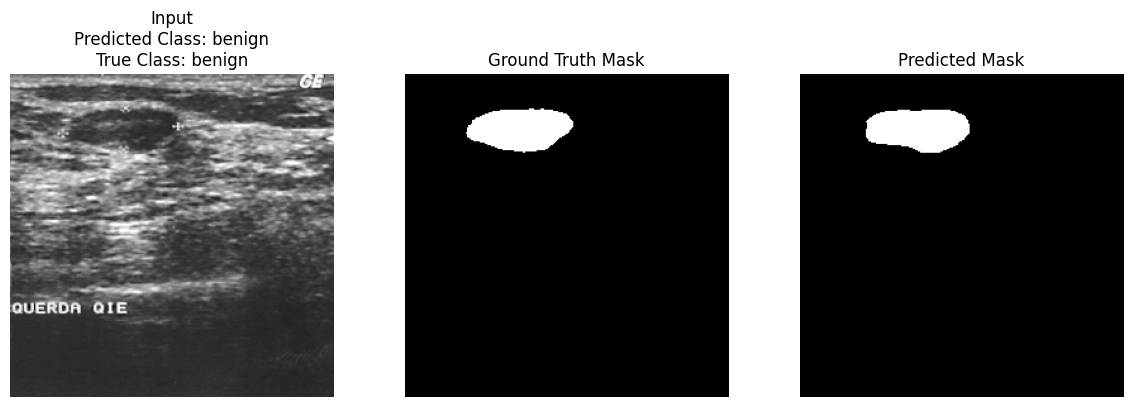

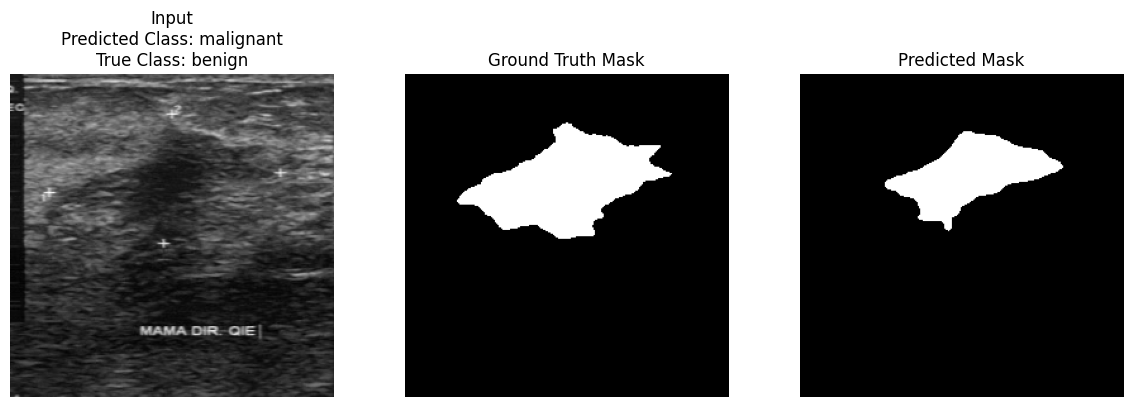

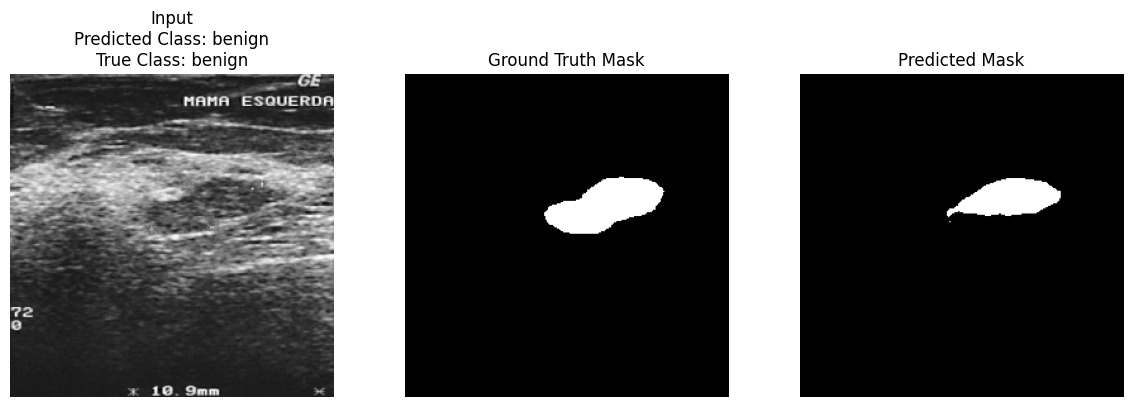

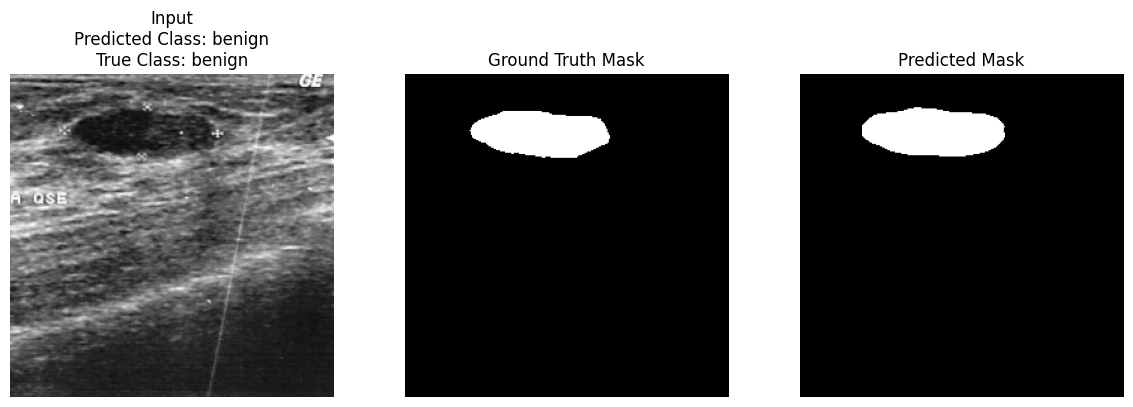

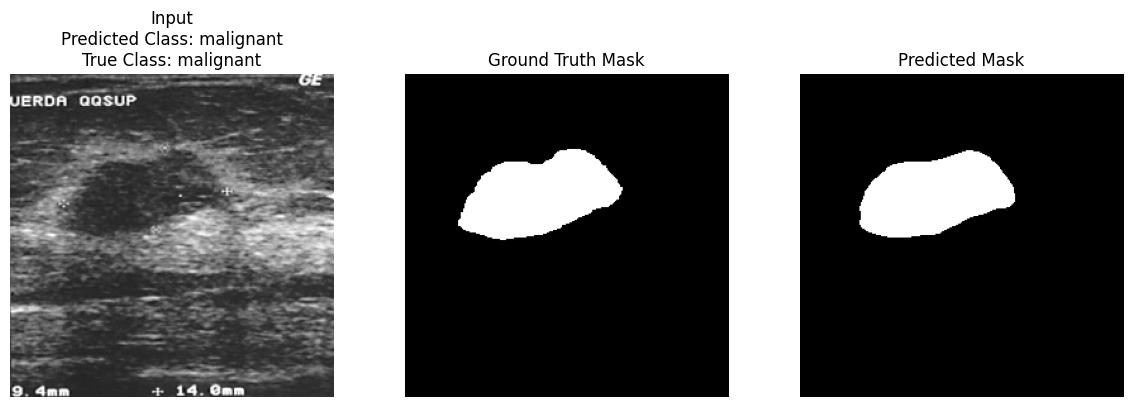

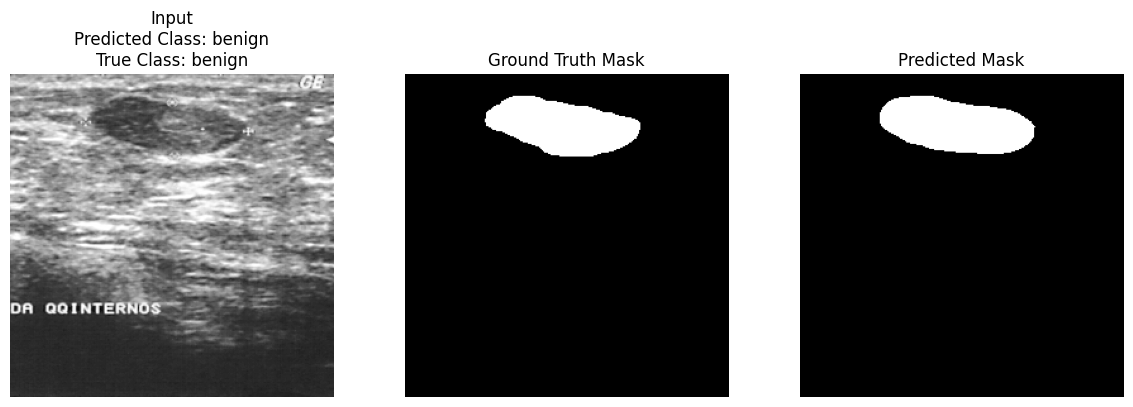

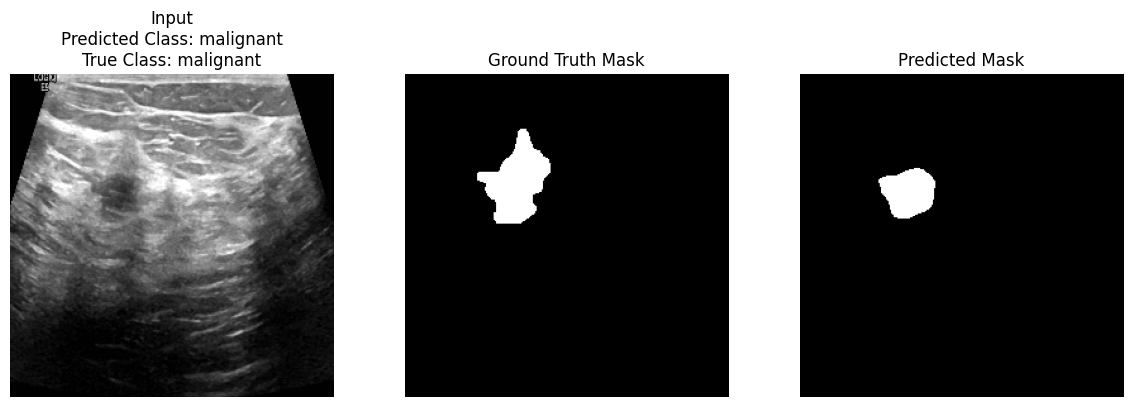

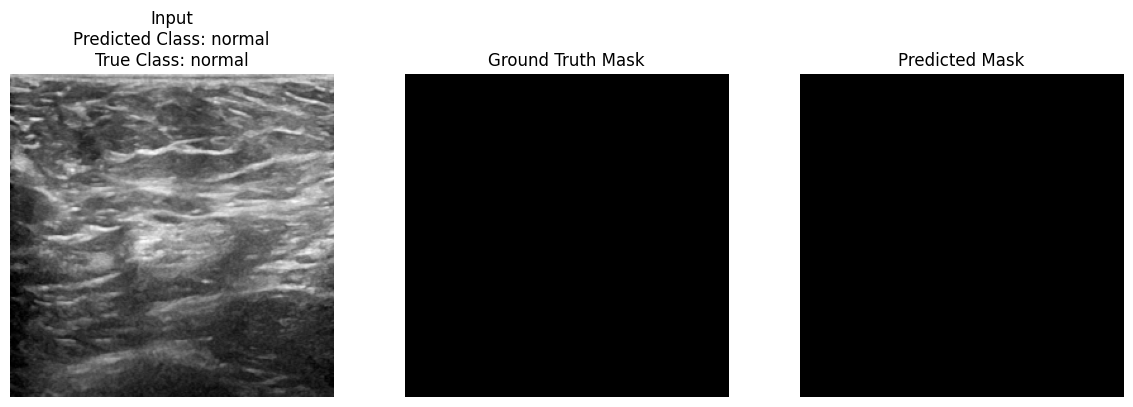

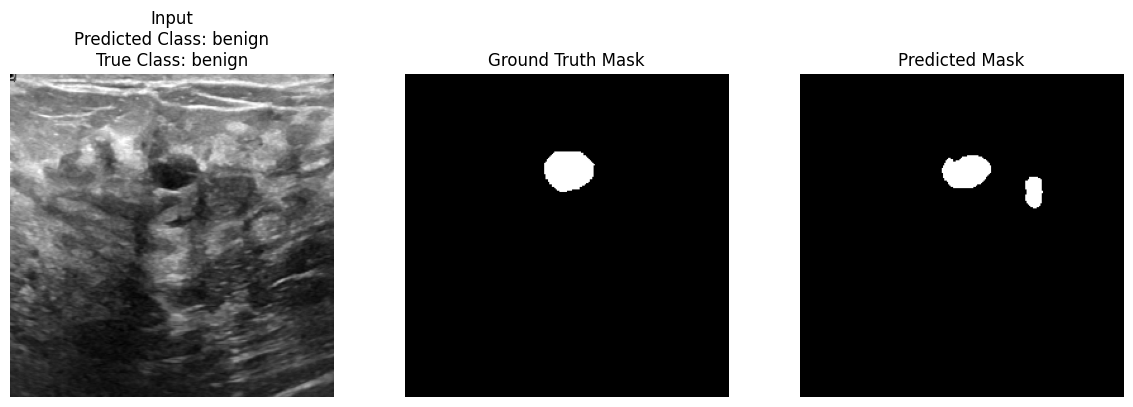

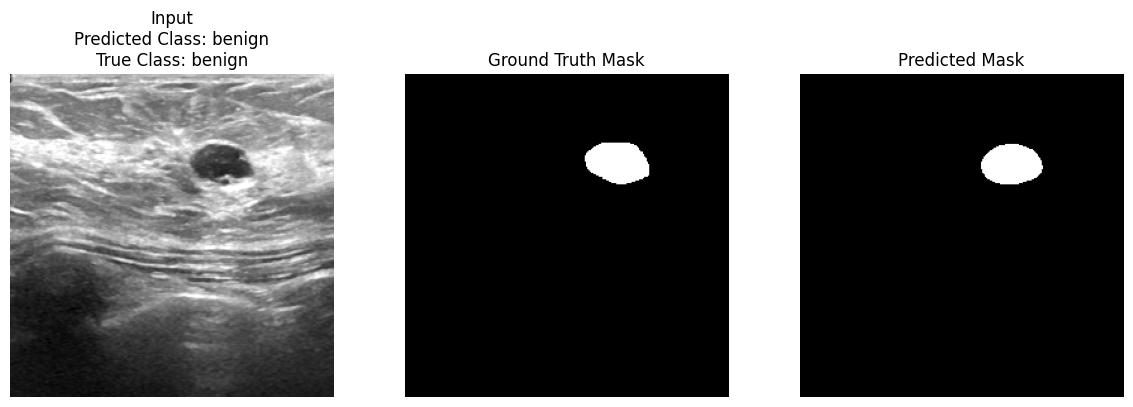

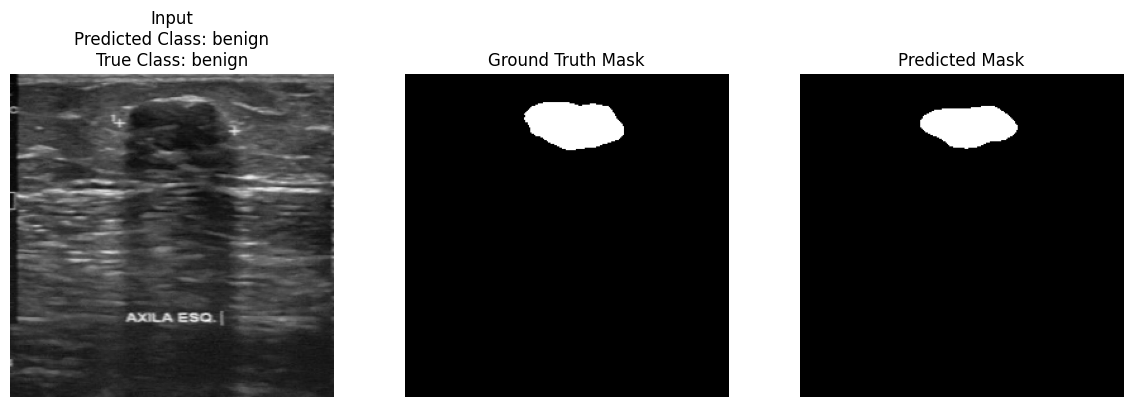

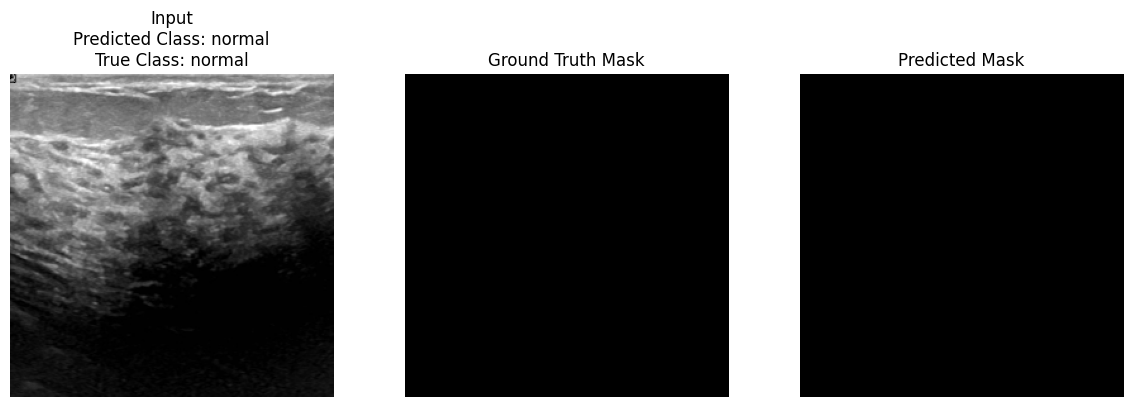

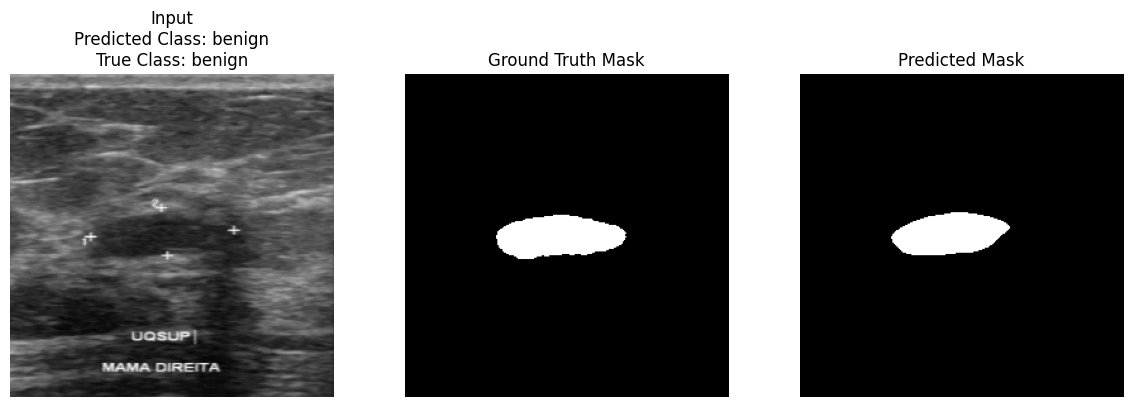

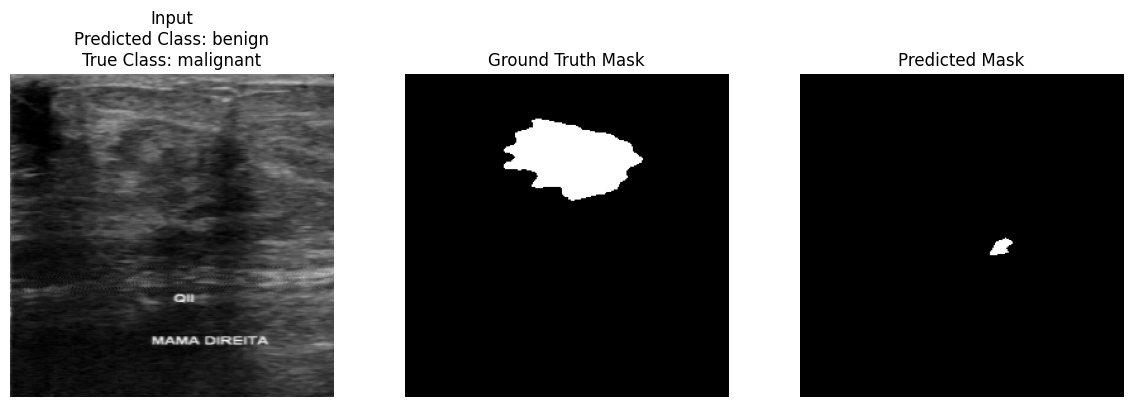

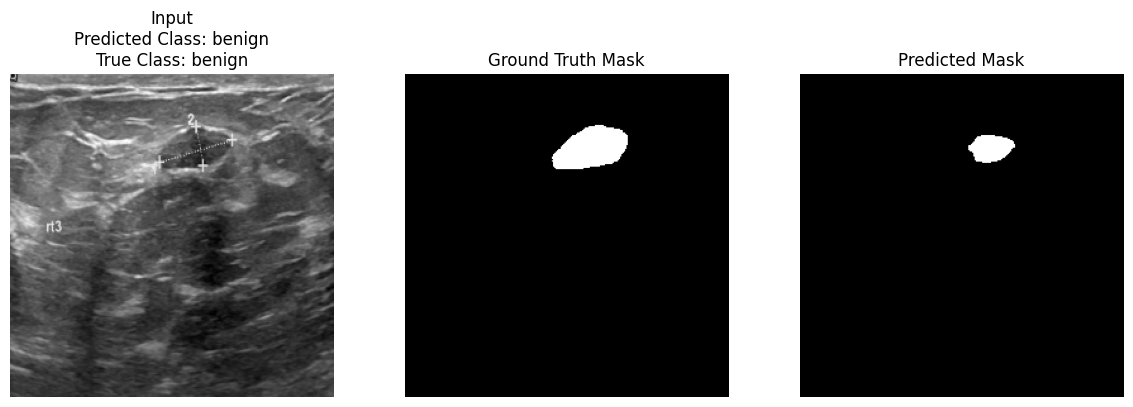

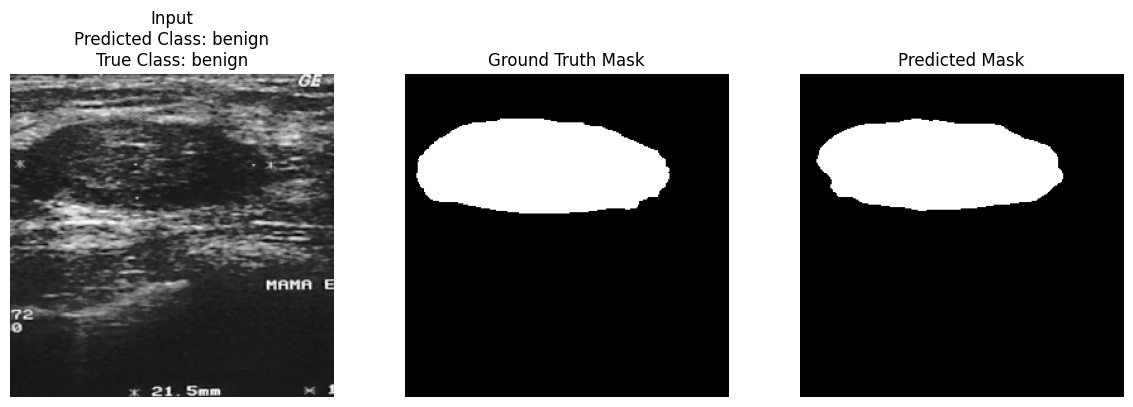

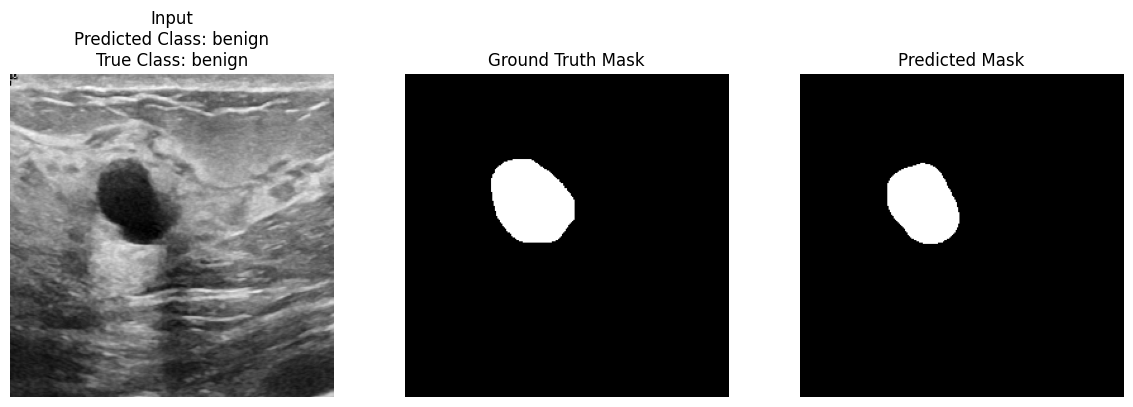

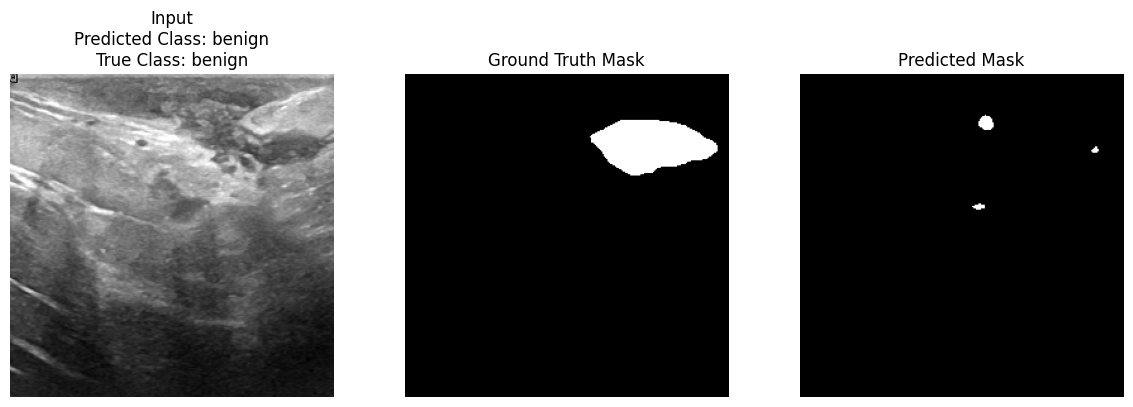

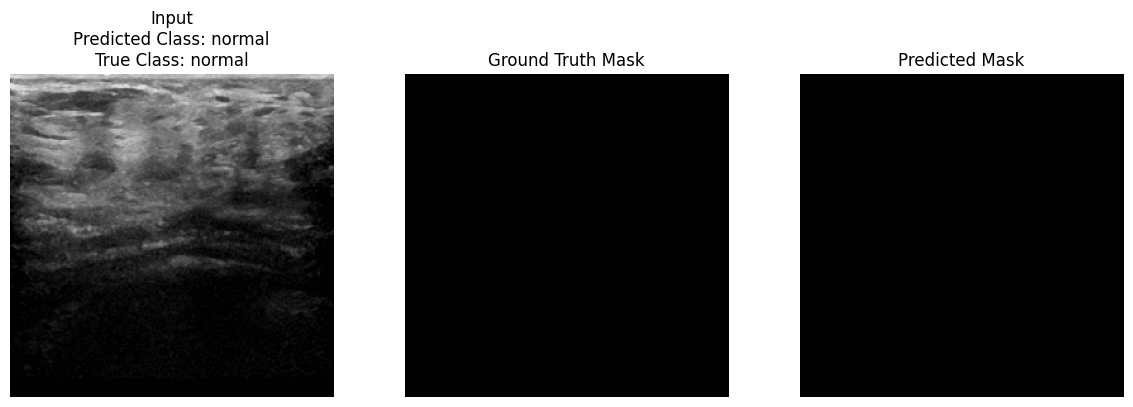

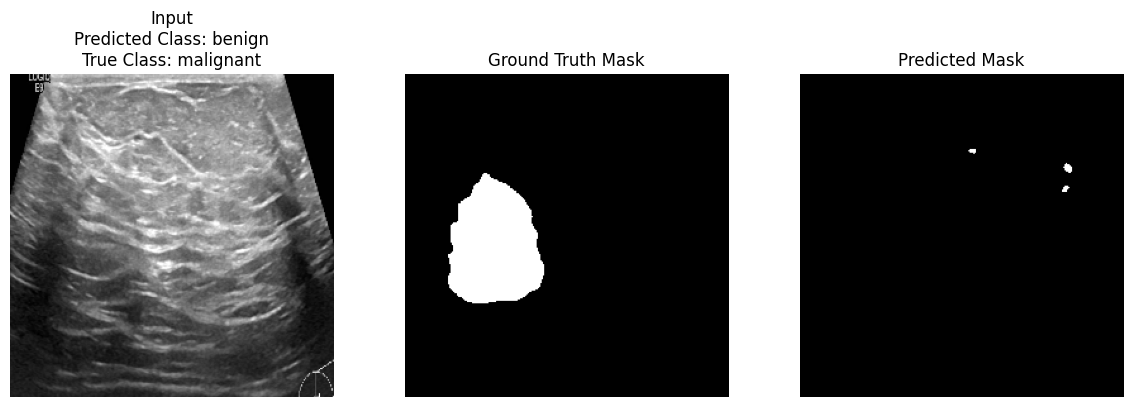

In [40]:
class_map = {0: "benign", 1: "malignant", 2: "normal"}
show_predictions(model, test_loader, class_map=class_map, num_samples=20)

# Submission

In [41]:
test_root = "/kaggle/working/precise-challenge-dataset/PRECISE_Challenge2025_Val"
image_paths = sorted(glob.glob(os.path.join(test_root, "*", "*.png")))

# Generate image_id (without extension)
image_ids = [os.path.splitext(os.path.basename(p))[0] for p in image_paths]

def test_collate_fn(batch):
    images, image_ids, original_sizes = zip(*batch)
    return torch.stack(images), image_ids, original_sizes  # original_sizes stays a list of (H, W)

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, target_size=(256, 256), reference_image=None):
        self.image_paths = image_paths
        self.target_size = target_size
        self.reference_image = reference_image  # Used for histogram matching

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image_id = os.path.splitext(os.path.basename(path))[0]

        img = np.array(Image.open(path))
        original_size = img.shape[:2]  # (H, W)

        img = preprocess_image(img, target_size=self.target_size, reference_image=self.reference_image)
        img = np.expand_dims(img, axis=0)             # (1, H, W)
        img = np.repeat(img, 3, axis=0)               # (3, H, W)

        return torch.tensor(img, dtype=torch.float32), image_id, original_size

In [42]:
test_dataset = TestDataset(image_paths, target_size=(256, 256), reference_image=avg_reference)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=8, shuffle=False, collate_fn=test_collate_fn
)


# Load model
model = UNetConvNeXt(num_classes=3, seg_out_channels=1).to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Class map
class_map = {0: "Benign", 1: "Malignant", 2: "Normal"}

# Output folders
os.makedirs("PACE2025_PhaseI_Submission/segmentation", exist_ok=True)
csv_entries = []

from torchvision.transforms.functional import to_pil_image

with torch.no_grad():
    for batch_imgs, batch_ids, original_sizes in tqdm(test_loader, desc="Generating Submission"):
        batch_imgs = batch_imgs.to(device)

        seg_preds, cls_preds = model(batch_imgs)
        seg_probs = torch.sigmoid(seg_preds)
        cls_probs = torch.softmax(cls_preds, dim=1)
        cls_labels = torch.argmax(cls_probs, dim=1)

        for i in range(len(batch_ids)):
            image_id = batch_ids[i]
            label = class_map[cls_labels[i].item()]
            csv_entries.append((image_id, label))
        
            mask_np = (seg_probs[i, 0] > 0.5).cpu().numpy().astype(np.uint8)
            original_h, original_w = map(int, original_sizes[i])
            mask_resized = cv2.resize(mask_np, (original_w, original_h), interpolation=cv2.INTER_NEAREST)
        
            save_path = f"PACE2025_PhaseI_Submission/segmentation/{image_id}_mask.png"
            Image.fromarray(mask_resized * 255).convert("L").save(save_path)



Generating Submission: 100%|██████████| 69/69 [00:14<00:00,  4.63it/s]


In [43]:
# print(original_sizes[i])

In [44]:
df = pd.DataFrame(csv_entries, columns=["image_id", "label"])
df.to_csv("PACE2025_PhaseI_Submission/classification.csv", index=False)
print("✅ Submission files created.")

✅ Submission files created.


# View sample submition

In [45]:
def visualize_submission_samples(num_samples=5, submission_root="PACE2025_PhaseI_Submission", test_root=None):
    # Load classification.csv
    csv_path = os.path.join(submission_root, "classification.csv")
    df = pd.read_csv(csv_path)

    # Pick random samples
    samples = df.sample(n=num_samples, random_state=42)

    for _, row in samples.iterrows():
        image_id = row['image_id']
        label = row['label']

        # Load predicted mask
        
        mask_path = os.path.join(submission_root, "segmentation", f"{image_id}_mask.png")
        mask = np.array(Image.open(mask_path))

        # Load original image if test_root is provided
        img = None
        if test_root:
            img_path = glob.glob(os.path.join(test_root, "**", f"{image_id}.png"), recursive=True)
            if img_path:
                img = np.array(Image.open(img_path[0]))
                if len(img.shape) == 3:
                    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Plot
        fig, axs = plt.subplots(1, 2 if img is not None else 1, figsize=(10, 5))
        axs = [axs] if img is None else axs

        if img is not None:
            axs[0].imshow(img, cmap="gray")
            axs[0].set_title(f"{image_id} (Pred: {label})\nOriginal Image")
            axs[0].axis('off')

            axs[1].imshow(mask, cmap="gray")
            axs[1].set_title("Predicted Mask")
            axs[1].axis('off')
        else:
            axs[0].imshow(mask, cmap="gray")
            axs[0].set_title(f"{image_id} (Pred: {label})\nPredicted Mask")
            axs[0].axis('off')

        plt.tight_layout()
        plt.show()


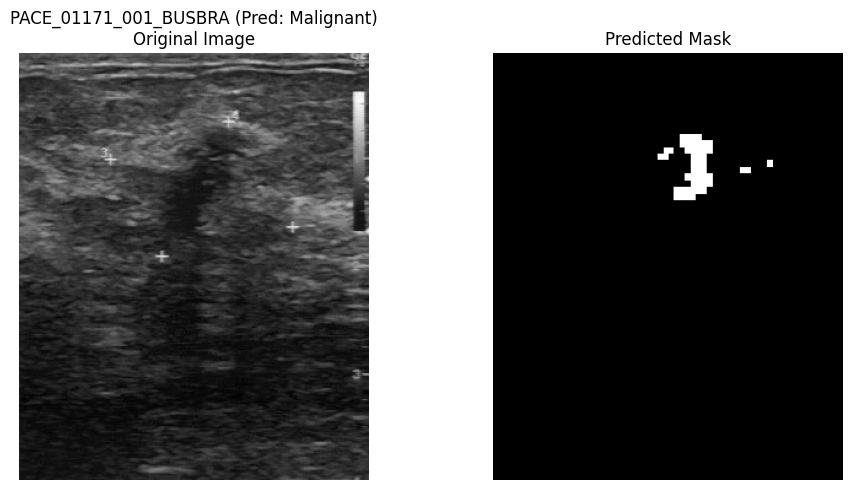

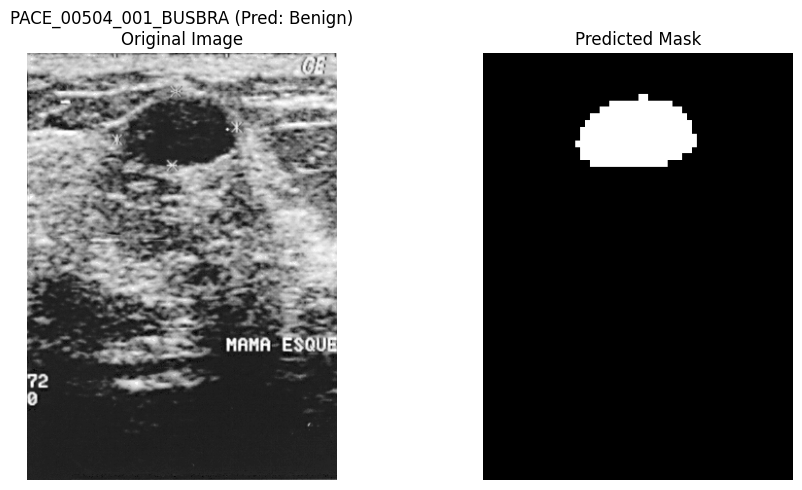

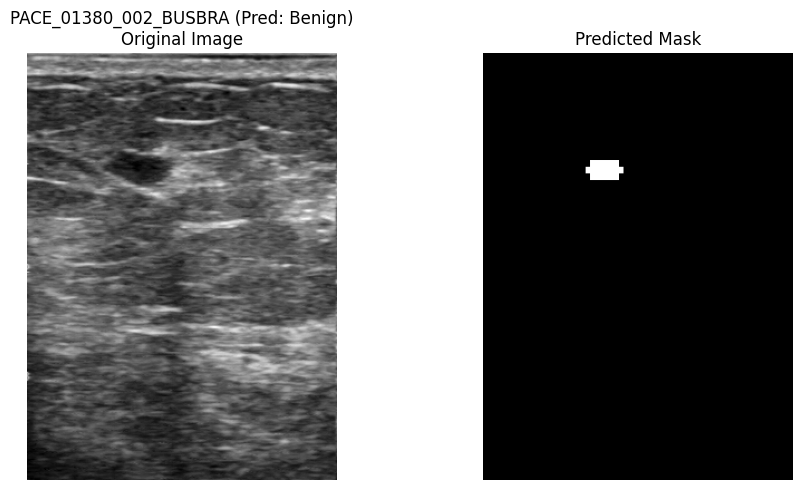

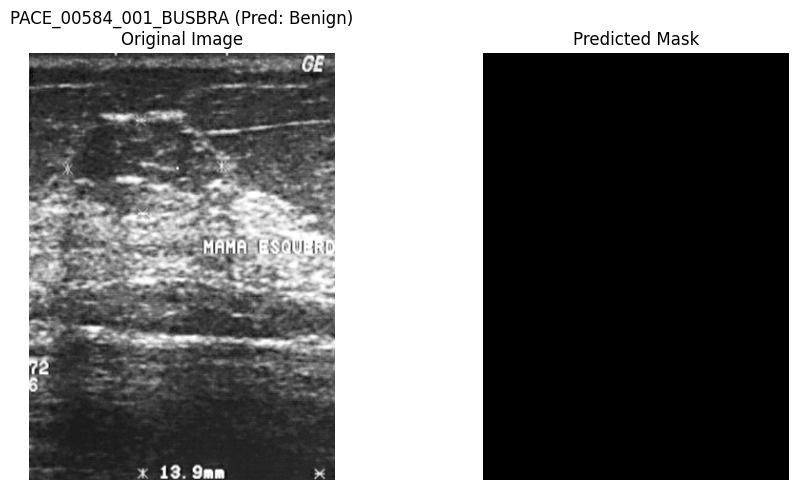

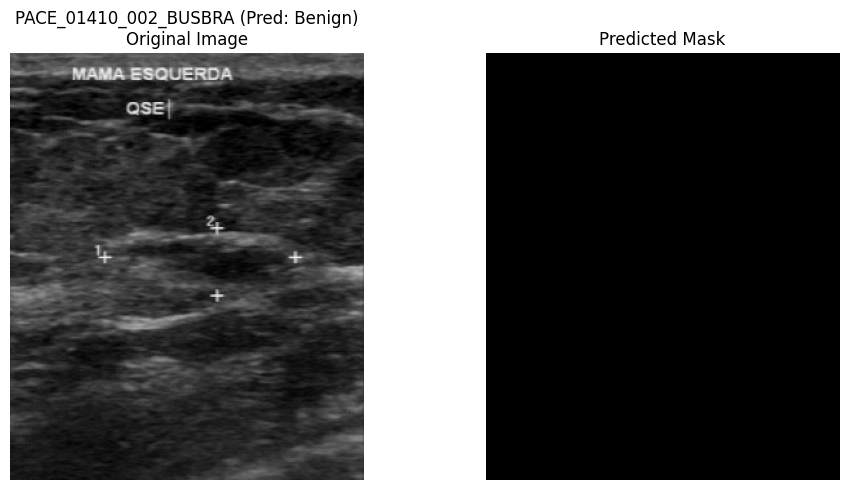

In [46]:
visualize_submission_samples(
    num_samples=5,
    submission_root="PACE2025_PhaseI_Submission",
    test_root="/kaggle/working/precise-challenge-dataset/PRECISE_Challenge2025_Val"
)

# Zip Submission

In [47]:
import shutil

shutil.make_archive("PACE2025_PhaseI_Submission", 'zip', "PACE2025_PhaseI_Submission")
print("Done")

Done


In [48]:
# import pandas
# pandas.read_csv('/kaggle/working/PACE2025_PhaseI_Submission/classification.csv')